## **Exploratory Data Analysis (EDA)**

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualización
sns.set_style("whitegrid")


In [2]:
# 2. Carga del conjunto de datos
df = pd.read_csv(
    r'C:\Users\LENOVO\Documentos\Marco\Data-Science\ar_properties.csv')


In [3]:
# Inspección inicial
df.head(3)  # Visualización de las primeras filas del dataset

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,wdQ5hWhv8P14T7Sh9g4QCg==,Propiedad,2020-12-25,9999-12-31,2020-12-25,-32.716652,-68.642692,Argentina,Mendoza,NaN,...,NaN,350.0,350.0,NaN,NaN,NaN,Excelentes Lotes Sobre Ruta 34,Corredor Responsable: VICTOR E. MONTIVERO - C....,Lote,Venta
1,nnMBYZ4RMRY+vm753EtA+g==,Propiedad,2020-12-25,9999-12-31,2020-12-25,-24.797723,-65.467514,Argentina,Salta,NaN,...,NaN,1541.0,1541.0,NaN,NaN,Mensual,TERRENO + VENTA + JARDINES DE SAN LORENZO +150...,Corredor Responsable: Pablo Castañeda - C.U.C....,Lote,Venta
2,+dnVA1K6JxzL1zAjOEQ1pA==,Propiedad,2020-12-25,2020-12-29,2020-12-25,-34.919373,-58.020591,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,...,NaN,1000.0,1000.0,NaN,NaN,Mensual,Lote en Venta de 1000 m2 en La Plata,Corredor Responsable: Rico Sebastián - Martill...,Lote,Venta


Variable 'id', 'title' y 'description' no contienen información relevante

In [4]:
df.info() # Información del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1000000 non-null  object 
 1   ad_type          1000000 non-null  object 
 2   start_date       1000000 non-null  object 
 3   end_date         1000000 non-null  object 
 4   created_on       1000000 non-null  object 
 5   lat              849189 non-null   float64
 6   lon              848255 non-null   float64
 7   l1               1000000 non-null  object 
 8   l2               1000000 non-null  object 
 9   l3               946673 non-null   object 
 10  l4               239496 non-null   object 
 11  l5               5001 non-null     object 
 12  l6               0 non-null        float64
 13  rooms            526423 non-null   float64
 14  bedrooms         466213 non-null   float64
 15  bathrooms        776733 non-null   float64
 16  surface_total    37

Variable 'l6' no contiene valores por lo que será eliminada. Se analizará acción a tomar con valores nulos

In [5]:
df.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'price', 'currency', 'price_period',
       'title', 'description', 'property_type', 'operation_type'],
      dtype='object')

In [6]:
df.describe()

,lat,lon,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,849189.000000,848255.000000,0.0,526423.000000,466213.000000,776733.000000,379501.000000,3.814510e+05,9.630980e+05
mean,-34.790048,-59.256701,NaN,2.861982,2.104534,1.707951,514.889481,6.123054e+03,3.285948e+05
std,2.957449,2.638051,NaN,1.689448,2.399252,1.080390,4372.302647,3.477565e+06,1.192329e+07
min,-54.841484,-119.699390,NaN,1.000000,-16.000000,1.000000,-136.000000,-1.300000e+02,0.000000e+00
25%,-34.919952,-58.746835,NaN,2.000000,1.000000,1.000000,50.000000,4.500000e+01,4.200000e+04
50%,-34.611445,-58.448442,NaN,3.000000,2.000000,1.000000,95.000000,7.600000e+01,9.800000e+04
75%,-34.456179,-58.172063,NaN,4.000000,3.000000,2.000000,255.000000,1.640000e+02,2.100000e+05
max,85.051129,-1.981231,NaN,40.000000,900.000000,20.000000,200000.000000,2.147484e+09,1.000000e+10


Valores irreales (negativos o extremos). Se analizará acción a tomar

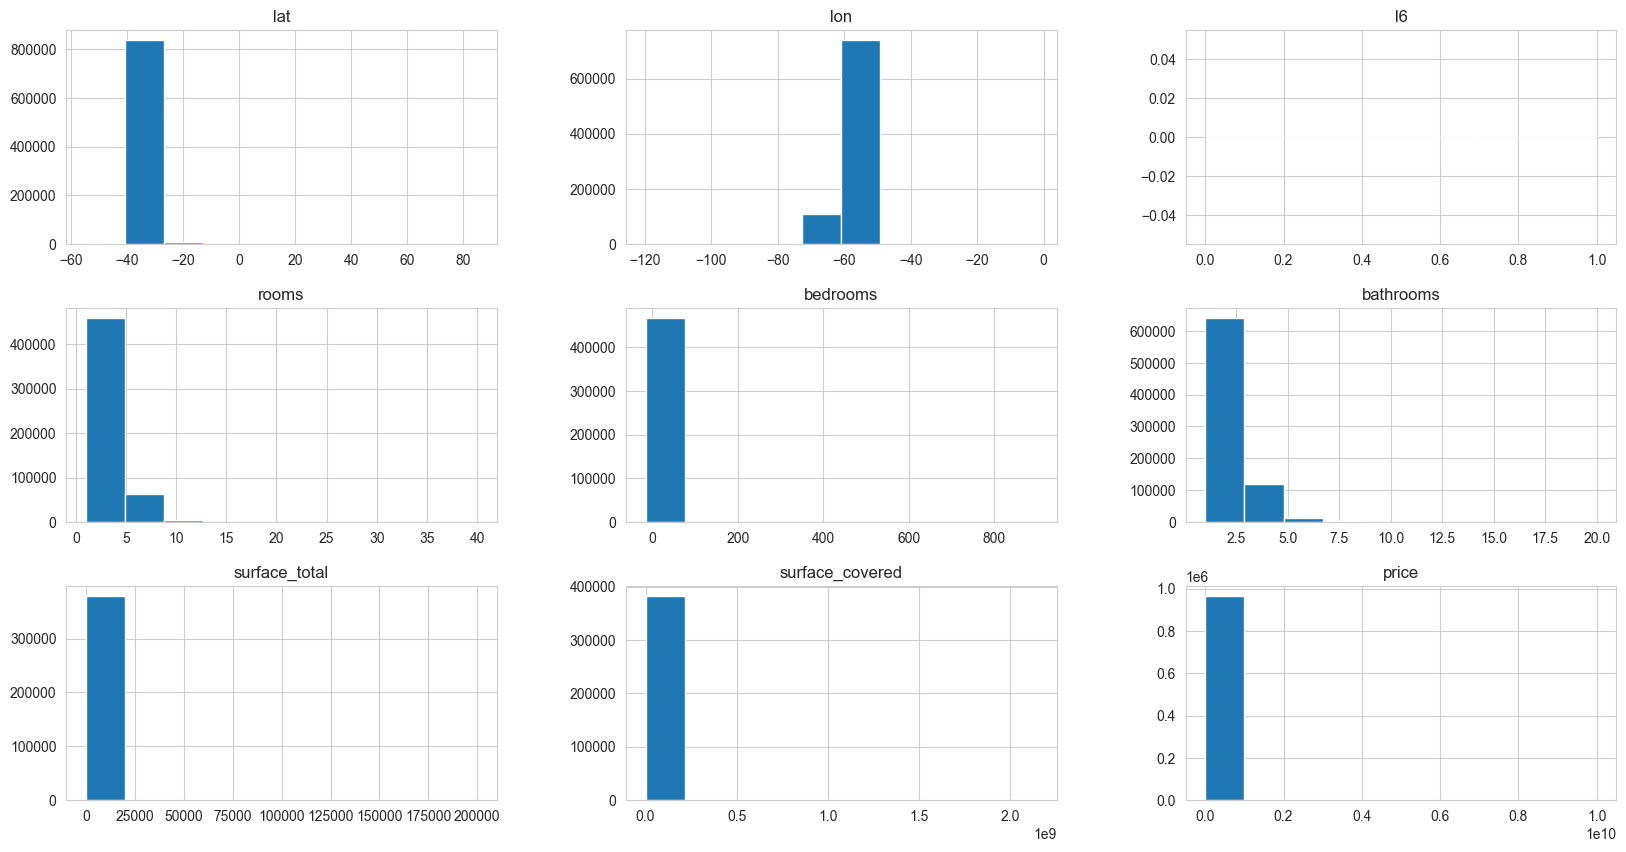

In [7]:
df.hist(figsize=(20,10))
plt.show()

#### **Se puede analizar algunas cuestiones:**

    - Contiene un millón de datos. Se pueden eliminar filas para reducir el tamaño del dataset y poder trabajar más rápido
    - 25 columnas de las cuales algunas no son relevantes para el análisis
    - Algunas de sus variables presentan una gran cantidad de valores nulos o sin sentido

#### Al haber tantos valores, se deduce que el trabajo requiere una gran limpieza de datos

### **Limpieza de datos**

In [8]:
df = df.drop(['l6'], axis=1, errors='ignore')  # Drop columna 'l6'

# Eliminación de valores faltantes en la columna 'price'
df = df[df['price'].notnull() == True]
df.shape

(963098, 24)

##### Información de variables

In [9]:
df['ad_type'].value_counts() # Valores y cantidad de la columna 'ad_type'

ad_type
Propiedad    963098
Name: count, dtype: int64

Ya que contiene un solo valor, se elimina la columna

In [10]:
df = df.drop('ad_type', axis=1, errors='ignore') # Drop columna 'ad_type'


In [11]:
df['operation_type'].value_counts() # Valores y cantidad de la columna 'operation_type'

operation_type
Venta                755922
Alquiler             177278
Alquiler temporal     29898
Name: count, dtype: int64

Se elimina 'Alquiler temporal ya que contiene pocos datos y alivianar el dataset

In [12]:
df = df[~(df['operation_type'] == 'Alquiler temporal')] # Drop filas donde 'operation_type' sea 'Alquiler temporal'


In [13]:
df['l1'].value_counts() # Valores y cantidad de la columna 'l1'

l1
Argentina         921386
Uruguay            11056
Estados Unidos       671
Brasil                87
Name: count, dtype: int64

Se eliminan todos los valores fuera de Argentina y luego se elimina la columna 'l1'

In [14]:
df = df[df['l1'] == 'Argentina']


In [15]:
df = df.drop('l1', axis=1)


In [16]:
df['property_type'].value_counts() # Valores y cantidad de la columna 'property_type'

property_type
Departamento       337813
Otro               235701
Casa               164751
Lote                77573
PH                  33526
Local comercial     31807
Oficina             24873
Cochera              8015
Depósito             6043
Casa de campo        1284
Name: count, dtype: int64

Se toman en cuenta simplemente los departamentos, casas y PHs ya que algunas variables no tienen sentido para las demás propiedades

In [17]:
df = df[(df['property_type'] == 'Departamento') | (
    df['property_type'] == 'Casa') | (df['property_type'] == 'PH')]


In [18]:
df.l5.value_counts() # Inspección variable 'l5'

l5
Barrio Los Alisos               591
BarrioPortezuelo                499
Barrio El Golf                  451
Barrio Los Lagos                233
Barrio Los Sauces               206
Barrio Los Tilos                185
Barrio Las Glorietas            152
Barrio Los Castores             146
Barrio Barrancas del Lago       134
Barrio La Alameda               118
Barrio Cabos del Lago           115
Barrio La Isla                   92
Barrio El Yacht                  91
Islas del Canal                  87
Barrio Lagos del Golf 1          70
Barrio Las Caletas               58
Barrio Lagos del Golf 2          56
Enyoi                            55
QBay Yacht                       29
Barrio Residencial Pacheco 1      5
Name: count, dtype: int64

Para no perder los datos, se guardan en una variable diferente y se borra la columna del dataframe

In [19]:
df_l5 = df.loc[df['l5'].isnull() == False]
df = df.drop('l5', axis=1)


In [20]:
print(df.currency.isnull().sum()) # Nulos en variable 'currency'
df['currency'].value_counts()  # Valores y cantidad de la columna 'currency'

848


currency
USD    419277
ARS    115795
PEN       170
Name: count, dtype: int64

Se eliminan valores tomados en moneda peruana y valores faltantes

In [21]:
df = df.loc[(df['currency'] == 'ARS') | (df['currency'] == 'USD')] # Nuevo df solo con monedas: 'ARS' y 'USD'


In [22]:
# Chequeo duplicados

df[df.duplicated(subset=None)]



,id,start_date,end_date,created_on,lat,lon,l2,l3,l4,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type


No hay datos duplicados en el dataset. Se investigará si sacando la variable 'id' se encuentran datos repetidos.

In [23]:
col = df.drop('id', axis=1, errors='ignore')
duplicados = df[col.duplicated(subset=col.columns)]
duplicados

,id,start_date,end_date,created_on,lat,lon,l2,l3,l4,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
43,UClZDZjF9Z4lOhP85mQSfA==,2020-12-25,2020-12-25,2020-12-25,-31.427785,-64.190612,Córdoba,Córdoba,Nueva Córdoba,2.0,...,1.0,NaN,NaN,15000.0,ARS,Mensual,B° NUEVA CÓRDOBA – DPTO. EN ALQUILER – 1 DORMI...,Ubicación: Obispo Trejo 1076 – Frente\r\n\r\nD...,Departamento,Alquiler
44,zTUNOcXYK6YS09xF4/3GYQ==,2020-12-25,2020-12-25,2020-12-25,-31.427785,-64.190612,Córdoba,Córdoba,Nueva Córdoba,2.0,...,1.0,NaN,NaN,15000.0,ARS,Mensual,B° NUEVA CÓRDOBA – DPTO. EN ALQUILER – 1 DORMI...,Ubicación: Obispo Trejo 1076 – Frente\r\n\r\nD...,Departamento,Alquiler
1059,tPaM266SjC+0ECaP3CBtCw==,2021-01-01,9999-12-31,2021-01-01,-34.814775,-58.465234,Bs.As. G.B.A. Zona Sur,Esteban Echeverría,Monte Grande,3.0,...,1.0,NaN,NaN,26000.0,ARS,Mensual,Departamento - Monte Grande,HERMOSO DEPTO EN MONTE GRANDE<br>ZONA CENTRICA...,Departamento,Alquiler
1109,raUWyJb05ATWGWfVqppkyg==,2021-01-01,9999-12-31,2021-01-01,-34.544221,-58.547588,Bs.As. G.B.A. Zona Norte,General San Martín,Villa Ballester,2.0,...,1.0,90.0,40.0,90000.0,USD,NaN,Departamento de 2 ambientes con terraza,Increble departamento de 2 ambientes a estrena...,Departamento,Venta
1186,Xu7z0i7uHa2xnILKT0zRzw==,2021-01-01,2021-01-13,2021-01-01,-34.658966,-58.618633,Bs.As. G.B.A. Zona Oeste,Morón,Morón,1.0,...,1.0,30.0,28.0,14000.0,ARS,Mensual,"Departamento de un ambiente en alquiler, Morón.",EXCELENTE DEPARTAMENTO DE UN AMBIENTE CON BALC...,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998238,TFV9QkQO2imC/RHlwMaGuw==,2020-05-12,2020-11-26,2020-05-12,NaN,NaN,Córdoba,Córdoba,NaN,2.0,...,3.0,NaN,186.0,410000.0,USD,NaN,Vilanova villa Belgrano deptos en venta / alqu...,Departamento en Venta de 3 dorm. en Cordoba,Departamento,Venta
999407,tavYa+m5HLdpEQ0mjwzQlw==,2020-05-12,2020-05-20,2020-05-12,-34.610187,-58.423543,Capital Federal,Almagro,NaN,3.0,...,2.0,65.0,62.0,123000.0,USD,Mensual,Departamento de 3 ambientes en Venta en Almagro,"NEGOCIABLE!!!, Hermoso 3 ambientes al contrafr...",Departamento,Venta
999422,jHaSNnXsUykqRszEJWnaYw==,2020-05-12,2020-05-20,2020-05-12,-34.575921,-58.421206,Capital Federal,Palermo,NaN,3.0,...,2.0,130.0,130.0,3300.0,USD,Mensual,U$S 3.300 - 3 amb amoblado - Cochera - Palermo...,PRECIO PAQUETEExpensas y ABL incluido.QUARTIER...,Departamento,Alquiler
999632,ExAsZ2eX+4NXGQIC8arX9g==,2020-05-12,2020-05-20,2020-05-12,-34.402698,-58.663971,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,NaN,...,3.0,671.0,220.0,410000.0,USD,Mensual,CASA A ESTRENAR EN VENTA EN BARRIO LOS LAGOS -...,"Casa de reconocida constructora, en venta en B...",Casa,Venta


Hay 8269 instancias que, con excepción de la 'id', contienen valores repetidos. Se eliminan las repeticiones y ya la columna 'id' no sirve así que también se quita del dataframe

In [24]:
# Nuevo dataframe sin valores repetidos y drop columna 'id'
df = df.drop_duplicates(subset=col.columns)
df = df.drop('id', axis=1, errors='ignore')


In [25]:
df[df['start_date'] != df['created_on']] # Chequeo si la columna 'start_date' es igual a la columna 'created_on'

,start_date,end_date,created_on,lat,lon,l2,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type


Son iguales por lo tanto se elimina la columna 'created_on'

In [26]:
df = df.drop('created_on', axis=1, errors='ignore') # Eliminación de columna 'created_on'


In [27]:
df.isnull().sum()

start_date              0
end_date                0
lat                 63112
lon                 63773
l2                      0
l3                  16773
l4                 375955
rooms              104444
bedrooms           150196
bathrooms           36400
surface_total      272622
surface_covered    248197
price                   0
currency                0
price_period       354852
title                   0
description             7
property_type           0
operation_type          0
dtype: int64

Se investiga acción a realizar para los valores faltantes en 'rooms', 'bedrooms','bathrooms','surface_total' y 'surface_covered'

In [28]:
df.isnull().mean().round(4)*100 # Proporción de nulos en cada variable

start_date          0.00
end_date            0.00
lat                11.98
lon                12.11
l2                  0.00
l3                  3.18
l4                 71.37
rooms              19.83
bedrooms           28.51
bathrooms           6.91
surface_total      51.75
surface_covered    47.11
price               0.00
currency            0.00
price_period       67.36
title               0.00
description         0.00
property_type       0.00
operation_type      0.00
dtype: float64

In [29]:
df.loc[df['rooms'] ==1].describe() # Estadísticas del dataframe cuando la cantidad de ambientes es 1

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,61080.000000,60694.000000,67795.0,27769.000000,62204.000000,35734.000000,38757.000000,6.779500e+04
mean,-34.391162,-59.259488,1.0,0.830062,1.037666,59.925505,45.164951,3.353069e+05
std,1.934151,2.157607,0.0,1.221168,0.239190,687.607339,333.334323,1.254891e+07
min,-54.812634,-72.274606,1.0,-1.000000,1.000000,10.000000,-2.000000,0.000000e+00
25%,-34.642037,-58.676995,1.0,0.000000,1.000000,32.000000,30.000000,2.300000e+04
50%,-34.595007,-58.454773,1.0,1.000000,1.000000,38.000000,35.000000,6.300000e+04
75%,-34.510616,-58.401644,1.0,1.000000,1.000000,45.000000,42.000000,1.000000e+05
max,42.287073,-2.539603,1.0,99.000000,11.000000,100000.000000,43000.000000,3.100000e+09


Para rellenar valores faltantes se toma la siguiente decisión:

- Para cada valor donde una variable es nula y las demás no, cambiar ese nulo por la mediana de ese valor cuando ninguna es nula.
- Por ejemplo, si cuando 'rooms' = 1 y 'bathrooms'= 1 la mediana de la variable 'bedrooms' = 1, se cambian los valores NaN de la variable 'bedrooms' por 1

In [30]:
# Eliminación de filas con muy poca información
df = df[~((df['rooms'].isnull() == True) & (df['bedrooms'].isnull() == True))]

Se eliminan instancias donde dos variables importantes son nulas

In [31]:
# Calcular la mediana de 'bedrooms' para cada combinación de 'rooms' y 'bathrooms'
median_bedrooms = df.groupby(['rooms', 'bathrooms'])['bedrooms'].transform('median')

# Rellenar los valores nulos de 'bedrooms' con la mediana correspondiente
df['bedrooms'] = df['bedrooms'].fillna(median_bedrooms)

Se repite el proceso para los NaN en la variable 'rooms'

In [32]:
# Calcular la mediana de 'bedrooms' para cada combinación de 'rooms' y 'bathrooms'
median_rooms = df.groupby(['bedrooms', 'bathrooms'])['rooms'].transform('median')

# Rellenar los valores nulos de 'bedrooms' con la mediana correspondiente
df['rooms'] = df['rooms'].fillna(median_rooms)

Se repite el proceso para los NaN en la variable 'bathrooms'

In [33]:
# Calcular la mediana de 'bathrooms' para cada combinación de 'rooms' y 'bedrooms'
median_bathrooms = df.groupby(['bedrooms', 'rooms'])['bathrooms'].transform('median')

# Rellenar los valores nulos de 'bedrooms' con la mediana correspondiente
df['bathrooms'] = df['bathrooms'].fillna(median_bathrooms)

In [34]:
df.isnull().mean().round(4)*100 # Proporción de nulos en cada variable

start_date          0.00
end_date            0.00
lat                11.55
lon                11.69
l2                  0.00
l3                  2.70
l4                 68.92
rooms               0.31
bedrooms            1.70
bathrooms           2.00
surface_total      46.49
surface_covered    41.28
price               0.00
currency            0.00
price_period       66.39
title               0.00
description         0.00
property_type       0.00
operation_type      0.00
dtype: float64

Para las variables de superficie se decide eliminar las fullas cuyos valores son nulos ya que son casi la mitad del dataset. Esto igualmente ayuda a reducir el tamaño y sigue siendo suficientemente grande

In [35]:
df = df.dropna(subset=['surface_total', 'surface_covered'])


In [36]:
df.isnull().mean().round(4)*100 # Proporción de nulos en cada variable

start_date          0.00
end_date            0.00
lat                11.43
lon                11.43
l2                  0.00
l3                  1.30
l4                 66.97
rooms               0.19
bedrooms            1.16
bathrooms           1.35
surface_total       0.00
surface_covered     0.00
price               0.00
currency            0.00
price_period       53.68
title               0.00
description         0.00
property_type       0.00
operation_type      0.00
dtype: float64

Se inspecciona por qué algunos valores todavía son nulos

In [37]:
prueba = df.drop('title', axis=1)
prueba.loc[df['rooms'].isnull() == True]


,start_date,end_date,lat,lon,l2,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,description,property_type,operation_type
3899,2020-06-07,2020-08-25,-34.600338,-58.424978,Capital Federal,Almagro,NaN,NaN,1.0,NaN,51.0,48.0,24000.0,ARS,Mensual,CODIGO: ubicado en: GUARDIA VIEJA 4288 - Pub...,Departamento,Alquiler
5224,2020-06-15,9999-12-31,-32.945206,-60.666318,Santa Fe,Rosario,NaN,NaN,1.0,NaN,68.0,68.0,115000.0,USD,Mensual,"VENDE Departamento de un dormitorio de 62,90...",Departamento,Venta
8453,2020-02-06,2020-05-20,-35.002980,-57.899501,Bs.As. G.B.A. Zona Sur,La Plata,NaN,NaN,3.0,NaN,433.0,190.0,120000.0,USD,NaN,Hermosa propiedad a 25 minutos de centro de La...,Casa,Venta
9503,2020-02-06,9999-12-31,-27.356811,-55.896643,Misiones,Posadas,NaN,NaN,3.0,NaN,216.0,170.0,180000.0,USD,Mensual,CODIGO: 87 ubicado en: RAMÓN GARCÍA Nº 976 - ...,Casa,Venta
11868,2020-02-01,2020-03-10,NaN,NaN,Bs.As. G.B.A. Zona Norte,Tigre,Rincón de Milberg,NaN,3.0,NaN,500.0,200.0,68000.0,ARS,NaN,ATENCIÓN: DISPONIBLE A PARTIR DE 1 ABRIL 2020<...,Casa,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988223,2020-07-06,2020-08-07,NaN,NaN,Bs.As. G.B.A. Zona Norte,San Isidro,San Isidro,NaN,3.0,NaN,472.0,294.0,2000.0,USD,NaN,"VILLA ITALIANA, excelente calidad de construcc...",Casa,Alquiler
996691,2020-05-03,2020-07-20,-34.392462,-58.650856,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,NaN,3.0,NaN,457.0,426.0,835000.0,USD,Mensual,Espectacular casa! Sólida construcción de gran...,Casa,Venta
996693,2020-05-03,2020-05-04,-34.411442,-58.671112,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,NaN,3.0,NaN,400.0,40.0,790000.0,USD,Mensual,Espectacular casa al lago! PB: Toilette de ...,Casa,Venta
996703,2020-05-03,2020-05-28,-34.422980,-58.665067,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,NaN,5.0,NaN,380.0,340.0,630000.0,USD,Mensual,Barrancas del Lago Lindisima Casa Pulte al lag...,Casa,Venta


Debido a que son instancias en las que hay dos variables nulas pero que no fueron eliminadas, se procede a borrarlas

In [38]:
df = df.dropna(subset=['rooms', 'bedrooms', 'bathrooms'])

##### Inspección de valores irreales

In [39]:
df.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,207568.000000,207568.000000,234251.000000,234251.000000,234251.000000,234251.000000,234251.000000,2.342510e+05
mean,-34.388480,-59.151373,3.082463,2.073231,1.703463,227.805841,130.398590,3.527763e+05
std,1.429160,2.061069,1.602404,1.176206,1.042674,1872.925113,1183.354692,6.603787e+06
min,-54.828087,-72.299316,1.000000,-1.000000,1.000000,-136.000000,-130.000000,5.000000e+01
25%,-34.620172,-58.676933,2.000000,1.000000,1.000000,50.000000,45.000000,5.990000e+04
50%,-34.586198,-58.472744,3.000000,2.000000,1.000000,80.000000,70.000000,1.250000e+05
75%,-34.461872,-58.417970,4.000000,3.000000,2.000000,178.000000,134.000000,2.450000e+05
max,-22.050635,-54.050372,32.000000,33.000000,16.000000,194273.000000,235000.000000,3.100000e+09


Variables 'bedrooms', 'surface_total', 'surface_covered' y 'price' con valores sin sentido

In [40]:
df[df['bedrooms'] < 0]


,start_date,end_date,lat,lon,l2,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
49558,2020-06-04,2020-06-30,-34.577927,-58.422944,Capital Federal,Palermo,NaN,2.0,-1.0,1.0,48.0,45.0,25000.0,ARS,NaN,Excelente Dos ambientes en Palermo,"Excelnte dos ambientes en dos plantas , muy lu...",Departamento,Alquiler
123648,2020-09-08,9999-12-31,-34.571572,-58.431867,Capital Federal,Palermo,NaN,2.0,-1.0,1.0,40.0,40.0,33000.0,ARS,NaN,Muy buen dos ambientes en alquiler temporario,"Muy buen dos ambientes , ubicada en lo mejor d...",Departamento,Alquiler
489731,2020-07-23,2020-08-18,-34.716259,-58.395588,Bs.As. G.B.A. Zona Sur,Lanús,Remedios de Escalada,2.0,-1.0,1.0,50.0,43.0,78500.0,USD,NaN,Venta Depto 2 ambientes con balcón y cochera e...,Venta de departamento 2 ambientes con balcón y...,Departamento,Venta
715771,2021-01-07,9999-12-31,-34.577595,-58.495185,Capital Federal,Villa Urquiza,NaN,2.0,-1.0,1.0,61.0,43.0,125000.0,USD,NaN,Jardines de Roosevelt - Hermoso 3 ambientes co...,Jardines de Roosevelt UF 547. Departamento de ...,Departamento,Venta


In [41]:
df['bedrooms'] = df['bedrooms'].abs() # Cambiamos sus valores a positivos

Se elimina ya que por lo general su variable 'surface_total' es NaN

In [42]:
df = df[~(df['surface_total'] < 15)] # Eliminación de instancias cuya superficie total sea menor a 15 metros cuadrados

In [43]:
df = df[~(df['surface_covered'] < 15)] # Eliminación de instancias cuya superficie cubierta sea menor a 15 metros cuadrados

In [44]:
df = df[df['price'] > 50] # Eliminación de instancias cuyo precio es menor a 50 ya que son valores muy bajos para ser reales

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233990 entries, 36 to 999981
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       233990 non-null  object 
 1   end_date         233990 non-null  object 
 2   lat              207342 non-null  float64
 3   lon              207342 non-null  float64
 4   l2               233990 non-null  object 
 5   l3               231015 non-null  object 
 6   l4               77375 non-null   object 
 7   rooms            233990 non-null  float64
 8   bedrooms         233990 non-null  float64
 9   bathrooms        233990 non-null  float64
 10  surface_total    233990 non-null  float64
 11  surface_covered  233990 non-null  float64
 12  price            233990 non-null  float64
 13  currency         233990 non-null  object 
 14  price_period     108159 non-null  object 
 15  title            233990 non-null  object 
 16  description      233990 non-null  object 


In [46]:
df['price_period'].value_counts() # Valores y cantidad de la columna 'price_period'

price_period
Mensual    108159
Name: count, dtype: int64

In [47]:
df[(df['price_period'].notnull() == True) & (df['operation_type'] == 'Venta')] # Filtrar df cuando 'price_period' sea no sea nulo y el tipo de operación sea 'Venta'

,start_date,end_date,lat,lon,l2,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
105,2020-12-25,9999-12-31,-34.911570,-57.960462,Bs.As. G.B.A. Zona Sur,La Plata,NaN,1.0,1.0,1.0,38.0,35.0,58000.0,USD,Mensual,Venta estrenar monoambiente céntrico - 42 e90 ...,Exclente calidad a estrenar. Living comedor am...,Departamento,Venta
125,2020-12-25,9999-12-31,-32.950769,-60.649344,Santa Fe,Rosario,NaN,2.0,1.0,1.0,49.0,49.0,50000.0,USD,Mensual,Departamento - Centro,Departamento de 1 dormitorio en excelente esta...,Departamento,Venta
128,2020-12-25,9999-12-31,-34.911694,-57.960537,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,2.0,1.0,1.0,50.0,48.0,80000.0,USD,Mensual,Venta estrenar 1 dormitorio - 42 e9 y 10 - La ...,Excelente calidad a estrenar. Living comedor a...,Departamento,Venta
129,2020-12-25,9999-12-31,-34.922166,-57.959022,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,2.0,1.0,1.0,45.0,43.0,75000.0,USD,Mensual,Venta depto. 1 dorm. - 49 e15 y 16 - La Plata,Al frente tipo pasante. Living comedor con bal...,Departamento,Venta
131,2020-12-25,2021-01-13,-34.918987,-57.939761,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,2.0,1.0,1.0,43.0,41.0,45000.0,USD,Mensual,Venta depto. 1 dormitorio - Av. 60 esq. 5 - La...,"Piso alto, excelente vista y luminosidad. Livi...",Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999958,2020-05-12,2020-05-20,-34.599085,-58.449254,Capital Federal,Villa Crespo,NaN,6.0,5.0,2.0,253.0,150.0,220001.0,USD,Mensual,Casa de 6 ambientes en Venta en Villa crespo,CASA CON LOCAL EN FUNCIONAMIENTO 2 PLANTAS ES ...,Casa,Venta
999967,2020-05-12,2020-09-28,-34.552132,-58.438501,Capital Federal,Belgrano,NaN,6.0,5.0,5.0,580.0,580.0,1111111.0,USD,Mensual,Casa en Forum Alcorta - Terraza con parrilla y...,"Casa en Forum Alcorta con pileta, quincho con ...",Departamento,Venta
999979,2020-05-12,2020-05-20,-34.602115,-58.405980,Capital Federal,Once,NaN,8.0,7.0,1.0,180.0,180.0,299001.0,USD,Mensual,Depto.tipo casa de 8 ambientes en Venta en Once,Departamento tipo casa a reciclar primer piso ...,PH,Venta
999980,2020-05-12,2020-05-20,-34.415320,-58.645990,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,9.0,7.0,8.0,800.0,800.0,3800000.0,USD,Mensual,Casa en venta al lago central,Imponente casa en la mejor cuadra del barrio E...,Casa,Venta


In [48]:
df[(df['price_period'].notnull() == False) & (df['operation_type'] == 'Alquiler')] # Filtrar df cuando 'price_period' sea nulo y la operación 'Alquiler'

,start_date,end_date,lat,lon,l2,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
36,2020-12-25,2021-01-08,-34.591216,-58.406686,Capital Federal,Recoleta,NaN,1.0,1.0,1.0,17.0,17.0,15000.0,ARS,NaN,Monoambiente en alquiler en Recoleta CABA,Corredor Responsable: Daniel Acosta - CUCICBA ...,Departamento,Alquiler
37,2020-12-25,2021-01-08,-34.637904,-58.502219,Capital Federal,Villa Luro,NaN,1.0,1.0,1.0,38.0,36.0,24000.0,ARS,NaN,Alquiler Monoambiente Villa Luro + Amenities,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Alquiler
41,2020-12-25,2021-01-05,-34.720874,-58.278099,Bs.As. G.B.A. Zona Sur,Quilmes,Quilmes,2.0,1.0,1.0,45.0,45.0,16000.0,ARS,NaN,ALQUILER. DPTO 2 AMB. CON COCHERA. QUILMES,Corredor Responsable: Martin Veltri - C.M.Q. 8...,Departamento,Alquiler
45,2020-12-25,2021-01-02,-34.591263,-58.410973,Capital Federal,Recoleta,NaN,2.0,1.0,1.0,39.0,38.0,21000.0,ARS,NaN,"Alquiler Departamento 2 ambientes,Interno Reco...",Corredor Responsable: MARIANO AUFSEHER - CPI 4...,Departamento,Alquiler
46,2020-12-25,2020-12-29,-38.946141,-68.049174,Neuquén,Confluencia,NaN,2.0,1.0,1.0,60.0,58.0,55000.0,ARS,NaN,DEPARTAMENTO UN DORMITORIO AMUEBLADO,Corredor Responsable: SEBASTIAN BONIFACIO - N°...,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997676,2020-05-12,2020-09-04,NaN,NaN,Bs.As. G.B.A. Zona Norte,Tigre,Tigre,4.0,3.0,4.0,246.0,246.0,2500.0,USD,NaN,Barrio La Comarca. Bancalari 100 - U$D 2.500 ...,Casa en 2 plantas en el Barrio La Comarca a la...,Casa,Alquiler
997682,2020-05-12,2020-08-28,NaN,NaN,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,5.0,4.0,7.0,400.0,400.0,3500.0,USD,NaN,El Yacht Lote / N° 100 - U$D 3.500 - Casa Alqu...,"Imperdible casa en El Yacht, Nordelta.4 dormit...",Casa,Alquiler
997760,2020-05-12,2020-06-11,-34.482414,-58.589127,Bs.As. G.B.A. Zona Norte,San Isidro,NaN,5.0,4.0,4.0,450.0,450.0,1800.0,USD,NaN,J De San Martin Lote / N° 500 - U$D 1.800 - Ca...,Ciudad:San isidro-Zona:Residencial-Asfalto-Obr...,Casa,Alquiler
999681,2020-05-12,2020-06-19,NaN,NaN,Bs.As. G.B.A. Zona Norte,San Isidro,San Isidro,4.0,3.0,2.0,421.0,320.0,800.0,USD,NaN,"Casa 421m² con Cochera en TEJEDOR, Carlos 300,...",IMPECABLE!!!! Ecelente casa: Hall de distribuc...,Casa,Alquiler


Se elimina la variable directamente. Por los precios vistos, se puede asumir un período mensual para los alquileres

In [49]:
df = df.drop('price_period', axis=1, errors='ignore')

In [50]:
df.isnull().sum() # Cantidad de nulos por variable

start_date              0
end_date                0
lat                 26648
lon                 26648
l2                      0
l3                   2975
l4                 156615
rooms                   0
bedrooms                0
bathrooms               0
surface_total           0
surface_covered         0
price                   0
currency                0
title                   0
description             0
property_type           0
operation_type          0
dtype: int64

Finalmente se guarda en diferentes variables el dataframe con las columnas que aún tienen valores nulos y se procede a eliminar esas columnas del dataframe ya que no influyen directamente en el objetivo del trabajo y ya se pueden eliminar las variables 'title' y 'description'

In [51]:
df = df.dropna(subset=['l3'])

In [52]:
lat_y_lon = df.loc[(df['lat'].isnull() == False) &
                   (df['lon'].isnull() == False)]



In [53]:
df_l4 = df.loc[df['l4'].isnull() == False]


In [54]:
df = df.drop(['l4', 'title', 'description','lat','lon'], axis=1, errors='ignore')


## Visualizaciones

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 231015 entries, 36 to 999981
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       231015 non-null  object 
 1   end_date         231015 non-null  object 
 2   l2               231015 non-null  object 
 3   l3               231015 non-null  object 
 4   rooms            231015 non-null  float64
 5   bedrooms         231015 non-null  float64
 6   bathrooms        231015 non-null  float64
 7   surface_total    231015 non-null  float64
 8   surface_covered  231015 non-null  float64
 9   price            231015 non-null  float64
 10  currency         231015 non-null  object 
 11  property_type    231015 non-null  object 
 12  operation_type   231015 non-null  object 
dtypes: float64(6), object(7)
memory usage: 24.7+ MB


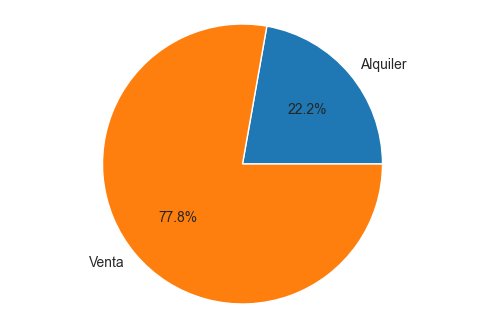

operation_type
Venta       179693
Alquiler     51322
Name: count, dtype: int64


In [56]:
# Análisis de cantidad de datos de alquileres vs ventas
plt.figure(figsize=(6, 4))
plt.pie(df['operation_type'].value_counts().sort_index(),
        labels=df['operation_type'].unique(), autopct='%1.1f%%')
plt.axis('equal')
plt.show()
print(df.operation_type.value_counts())

In [57]:
# Separación de datos en diferentes variables
alquiler = df.loc[df['operation_type'] == 'Alquiler']
venta = df.loc[df['operation_type'] == 'Venta']

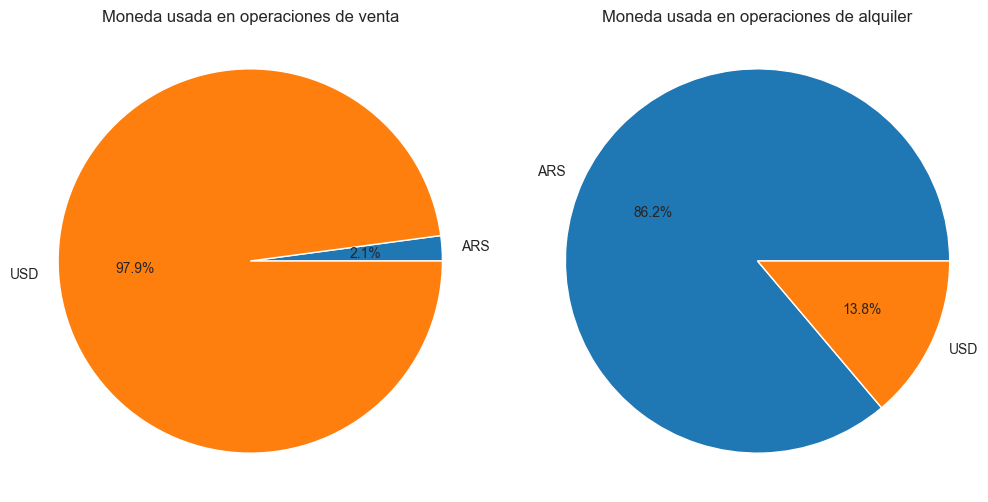

In [58]:
# Análisis de cantidad de datos de alquileres vs ventas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.pie(venta['currency'].value_counts().sort_index(),
        labels=venta['currency'].unique(), autopct='%1.1f%%')
ax1.set_title('Moneda usada en operaciones de venta')
ax2.pie(alquiler['currency'].value_counts().sort_index(),
        labels=alquiler['currency'].unique(), autopct='%1.1f%%')
ax2.set_title('Moneda usada en operaciones de alquiler')
ax1.axis('equal')
ax2.axis('equal')
plt.show()


In [59]:
ars = df.loc[df['currency'] == 'ARS']
usd = df.loc[df['currency'] == 'USD']

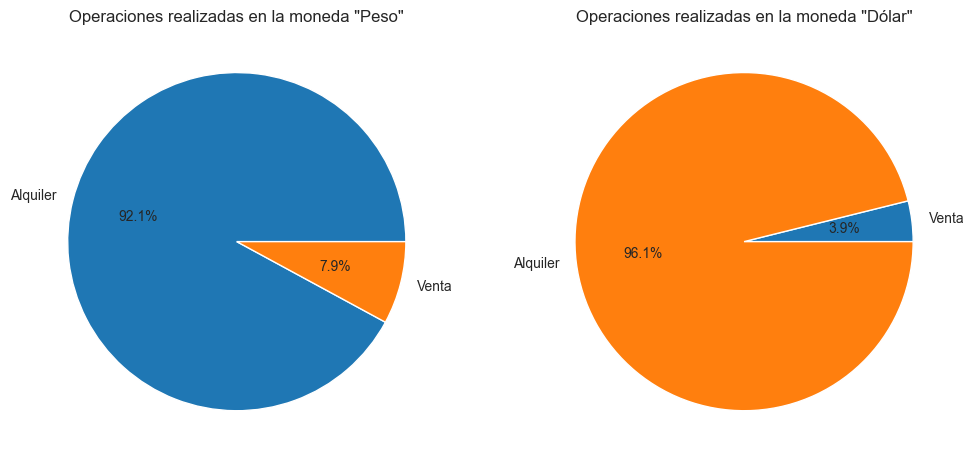

In [60]:
# Análisis de cantidad de datos de alquileres vs ventas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.pie(ars['operation_type'].value_counts().sort_index(),
        labels=ars['operation_type'].unique(), autopct='%1.1f%%')
ax1.set_title('Operaciones realizadas en la moneda "Peso"')
ax2.pie(usd['operation_type'].value_counts().sort_index(),
        labels=usd['operation_type'].unique(), autopct='%1.1f%%')
ax2.set_title('Operaciones realizadas en la moneda "Dólar"')
plt.show()

Debido a esto, se reduce el dataset en diferentes variables para visualizaciones. El alquiler por lo general es en pesos y la venta en dólares

In [61]:
alquiler_ars = pd.merge(alquiler, ars, how='inner')
venta_usd = pd.merge(venta, usd, how='inner')
alquiler_ars_caba = alquiler_ars.loc[alquiler_ars['l2'] == 'Capital Federal']
venta_usd_caba = venta_usd.loc[venta_usd['l2'] == 'Capital Federal']

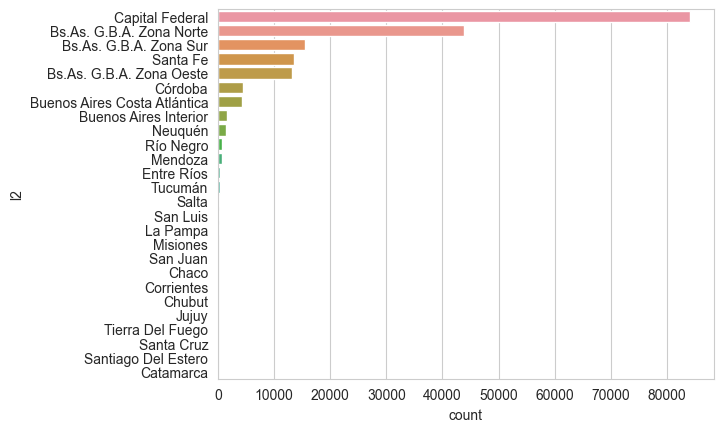

In [62]:
plt.figure()
sns.barplot(data = venta_usd, x = venta_usd.l2.value_counts(), y = venta_usd.l2.value_counts().index)
plt.show()

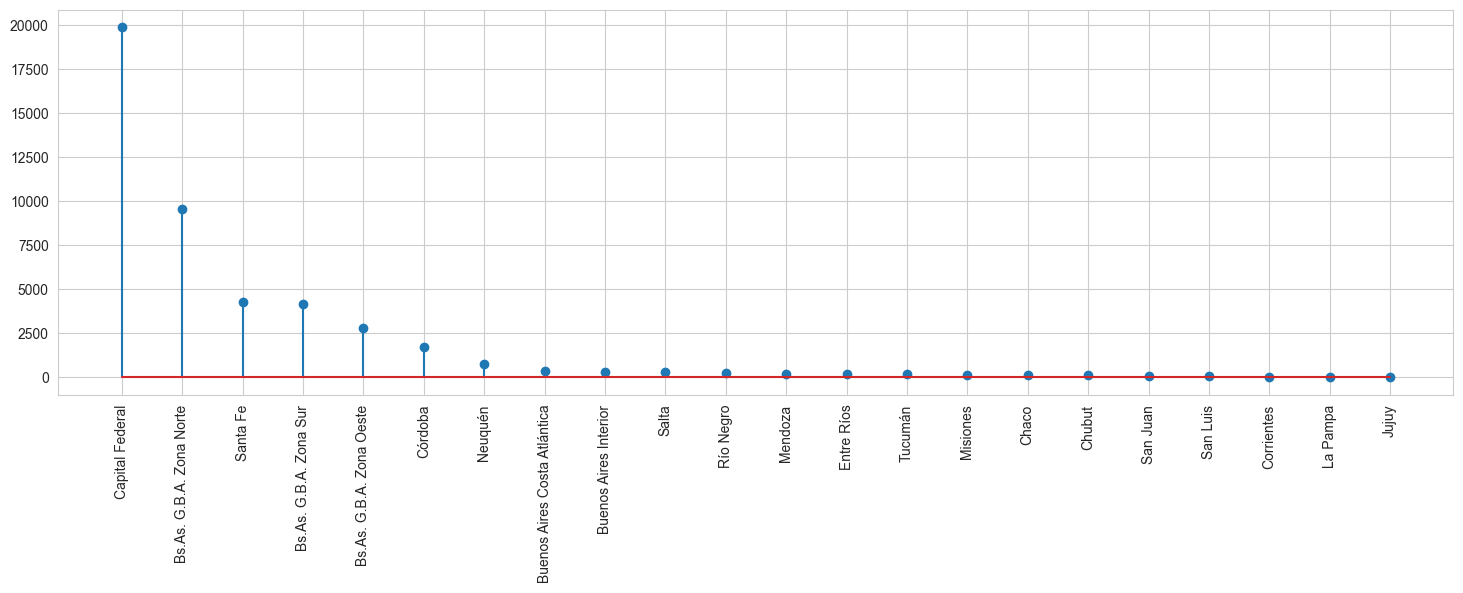

In [63]:
plt.figure(figsize=(18,5))
plt.stem(alquiler_ars.l2.value_counts())
plt.xticks(range(0, 22), alquiler_ars.l2.value_counts().index)
plt.xticks(rotation = 90)
plt.show()

In [64]:
# Separación de provincias con una baja cantidad de datos
valores_rep_venta = venta_usd['l2'].value_counts()[venta_usd['l2'].value_counts() > 1000]
valores_rep_venta

l2
Capital Federal                 84166
Bs.As. G.B.A. Zona Norte        43914
Bs.As. G.B.A. Zona Sur          15435
Santa Fe                        13567
Bs.As. G.B.A. Zona Oeste        13215
Córdoba                          4402
Buenos Aires Costa Atlántica     4250
Buenos Aires Interior            1627
Neuquén                          1364
Name: count, dtype: int64

In [65]:
# Separación de provincias con una baja cantidad de datos
valores_rep_alq = alquiler_ars['l2'].value_counts()[alquiler_ars['l2'].value_counts() > 600]
valores_rep_alq

l2
Capital Federal             19882
Bs.As. G.B.A. Zona Norte     9540
Santa Fe                     4279
Bs.As. G.B.A. Zona Sur       4158
Bs.As. G.B.A. Zona Oeste     2778
Córdoba                      1706
Neuquén                       739
Name: count, dtype: int64

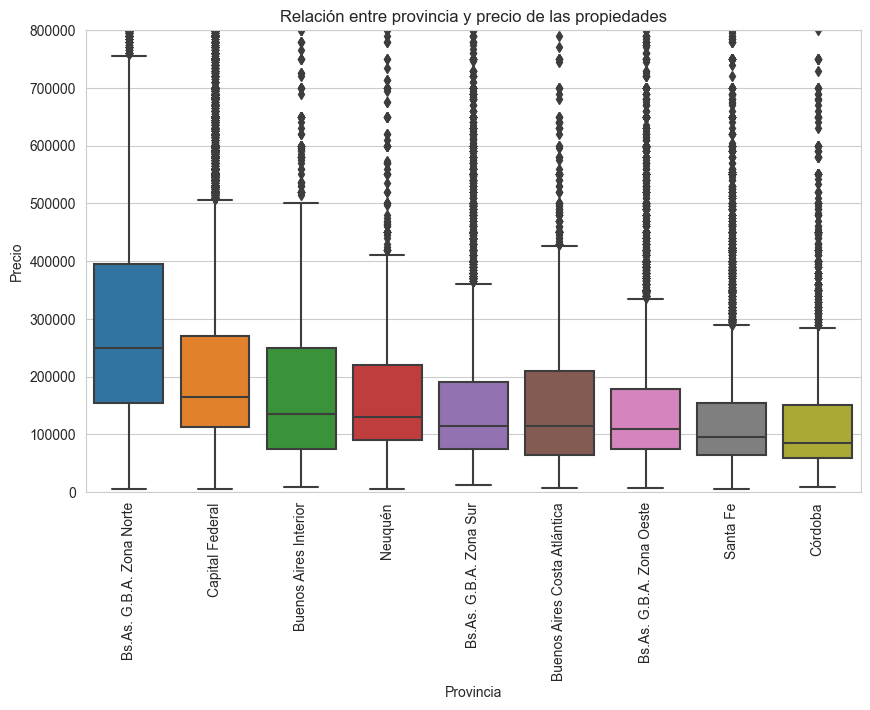

In [66]:
# Gráficos y visualizaciones

order = venta_usd[venta_usd['l2'].isin(valores_rep_venta.index)].groupby('l2')['price'].median().sort_values(ascending=False)

# Relación entre ubicación geográfica y precio
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='l2', y='price',
                 data=venta_usd[venta_usd['l2'].isin(valores_rep_venta.index)], order=order.index)
ax.set(xlabel='Provincia', ylabel='Precio',
       title='Relación entre provincia y precio de las propiedades', ylim=(0, 800000))
plt.xticks(rotation=90)
plt.show()


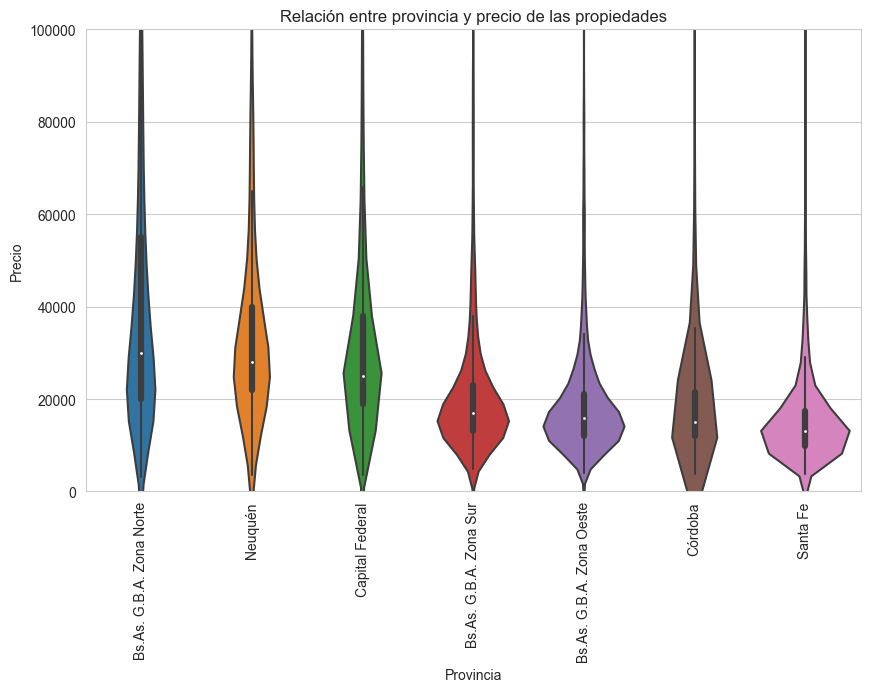

In [67]:
# Gráficos y visualizaciones

order = alquiler_ars[alquiler_ars['l2'].isin(valores_rep_alq.index)].groupby('l2')['price'].median().sort_values(ascending=False)

# Relación entre ubicación geográfica y precio
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x='l2', y='price',
                 data=alquiler_ars[alquiler_ars['l2'].isin(valores_rep_alq.index)], order=order.index)
ax.set(xlabel='Provincia', ylabel='Precio',
       title='Relación entre provincia y precio de las propiedades', ylim=(0, 100000))
plt.xticks(rotation=90)
plt.show()

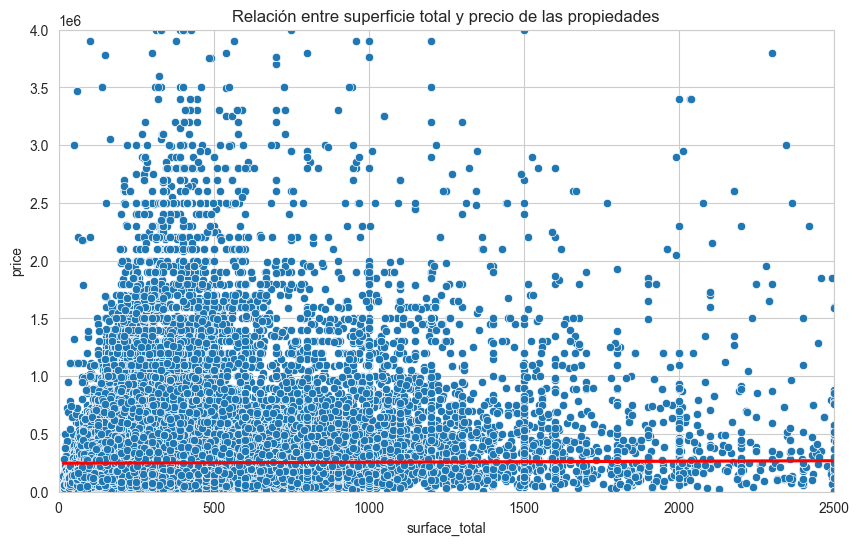

In [68]:
# Relación entre características físicas y precio
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='surface_total', y='price', data=venta_usd)
ax.set(xlabel='Superficie total', ylabel='Precio',
       title='Relación entre superficie total y precio de las propiedades', ylim=(0,4000000), xlim=(0,2500))
sns.regplot(x='surface_total', y='price', data=venta_usd, color='red', scatter=False)
plt.show()

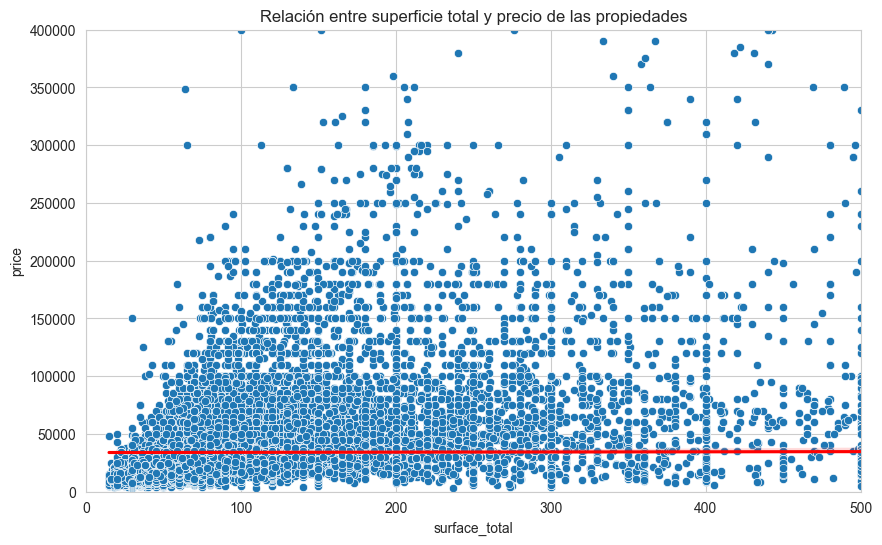

In [69]:
# Relación entre características físicas y precio
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='surface_total', y='price', data=alquiler_ars)
ax.set(xlabel='Superficie total', ylabel='Precio',
       title='Relación entre superficie total y precio de las propiedades', ylim=(0,400000), xlim=(0,500))
sns.regplot(x='surface_total', y='price', data=alquiler_ars, color='red', scatter=False)
plt.show()

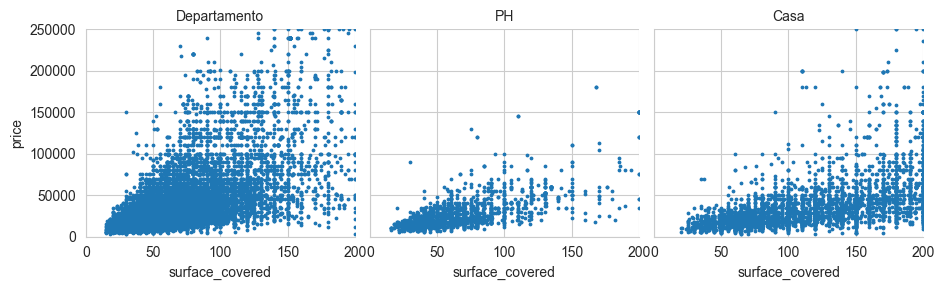

In [70]:
g = sns.FacetGrid(alquiler_ars, col='property_type', col_wrap=4)
g.map(plt.scatter, 'surface_covered', 'price', s=3)
g.set_titles('{col_name}')
g.set(ylim=(0,250000), xlim=(0,200))
plt.show()

In [71]:
venta_usd_caba.l3.value_counts()

l3
Palermo                 16078
Belgrano                 7233
Almagro                  6262
Villa Crespo             5800
Caballito                5187
Recoleta                 5000
Villa Urquiza            3516
Barrio Norte             2556
Nuñez                    2306
Colegiales               1969
Flores                   1901
Balvanera                1871
Puerto Madero            1868
Villa Devoto             1435
Villa del Parque         1283
Saavedra                 1228
San Telmo                1014
Parque Chacabuco          942
San Cristobal             906
Monserrat                 838
Floresta                  834
Retiro                    772
Boedo                     748
San Nicolás               719
Parque Centenario         718
Barracas                  715
Villa Pueyrredón          692
Chacarita                 689
Paternal                  669
Villa Luro                617
Coghlan                   534
Congreso                  526
Villa Ortuzar             515
Once   

In [72]:
# Separación de barrios con una baja cantidad de datos
valores_rep_caba = venta_usd_caba['l3'].value_counts()[venta_usd_caba['l3'].value_counts() > 800]

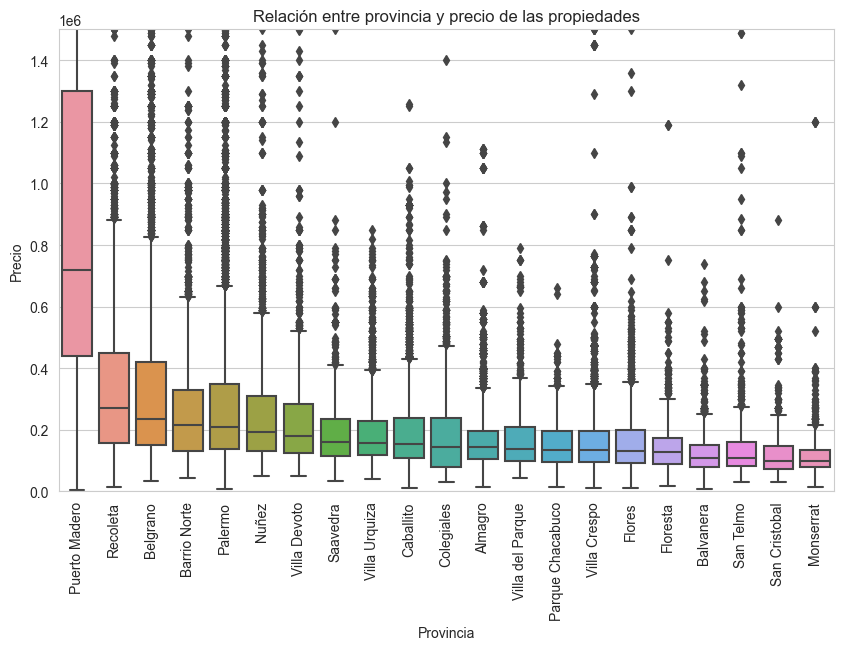

In [73]:
# Relación entre barrio y precio
order = venta_usd_caba[venta_usd_caba['l3'].isin(valores_rep_caba.index)].groupby(
    'l3')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='l3', y='price', data=venta_usd_caba[venta_usd_caba['l3'].isin(valores_rep_caba.index)], order=order.index)
ax.set(xlabel='Provincia', ylabel='Precio',
       title='Relación entre provincia y precio de las propiedades', ylim=(0, 1500000))
plt.xticks(rotation=90)
plt.show()

In [74]:
# Separación de variables numéricas para ver correclaciones
int_cols = df.select_dtypes(include='float')
int_cols

,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
36,1.0,1.0,1.0,17.0,17.0,15000.0
37,1.0,1.0,1.0,38.0,36.0,24000.0
38,1.0,1.0,1.0,39.0,39.0,16500.0
41,2.0,1.0,1.0,45.0,45.0,16000.0
45,2.0,1.0,1.0,39.0,38.0,21000.0
...,...,...,...,...,...,...
999967,6.0,5.0,5.0,580.0,580.0,1111111.0
999972,7.0,6.0,2.0,260.0,260.0,330000.0
999979,8.0,7.0,1.0,180.0,180.0,299001.0
999980,9.0,7.0,8.0,800.0,800.0,3800000.0


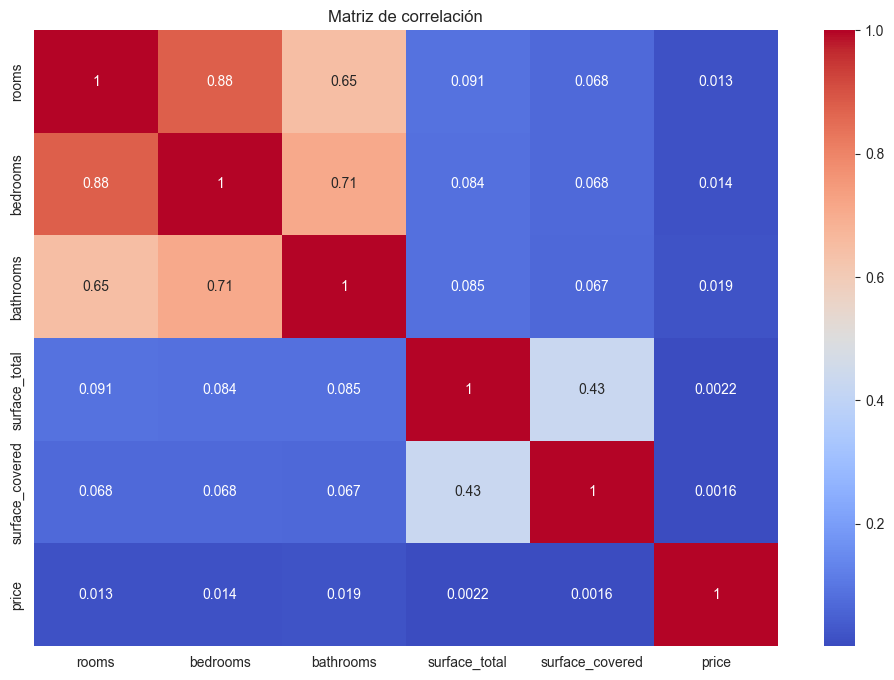

In [75]:
# Correlación entre características y precio
corr_matrix = int_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

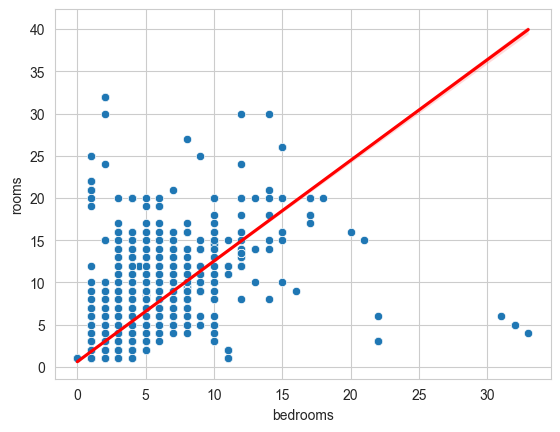

In [76]:
sns.scatterplot(data=df, x='bedrooms', y='rooms')
sns.regplot(x='bedrooms', y='rooms', data=df, color='red', scatter=False)
plt.show()


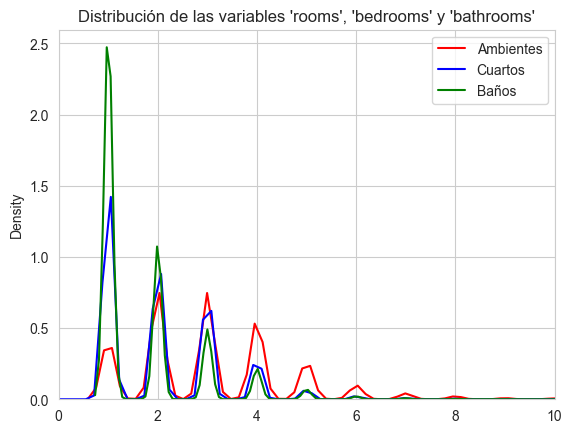

In [77]:
sns.kdeplot(data=df, x='rooms', color='red', label='Ambientes')
sns.kdeplot(data=df, x='bedrooms', color='blue', label='Cuartos')
sns.kdeplot(data=df, x='bathrooms', color='green', label='Baños')
plt.legend()
plt.xlabel(None)
plt.title("Distribución de las variables 'rooms', 'bedrooms' y 'bathrooms'")
plt.xlim(0,10)
plt.show()

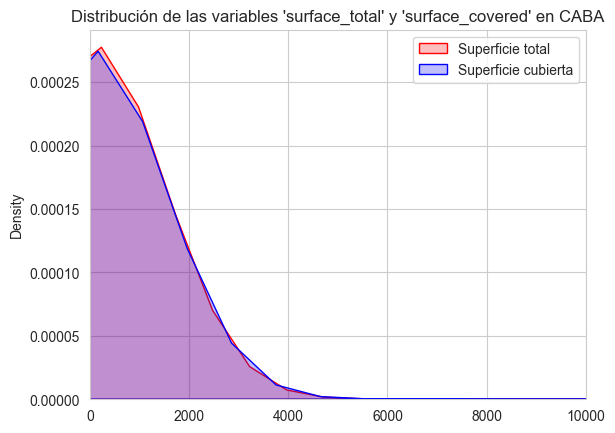

In [78]:
fig, ax = plt.subplots()
sns.kdeplot(data=venta_usd_caba, x='surface_total',
            color='red', label='Superficie total', fill=True, bw_adjust=10)
sns.kdeplot(data=venta_usd_caba, x='surface_covered',
            color='blue', label='Superficie cubierta', fill=True, bw_adjust=10)
ax.legend()
ax.set_xlabel(None)
ax.set_title(
    "Distribución de las variables 'surface_total' y 'surface_covered' en CABA")
ax.set_xlim(-10, 10000)
plt.show()


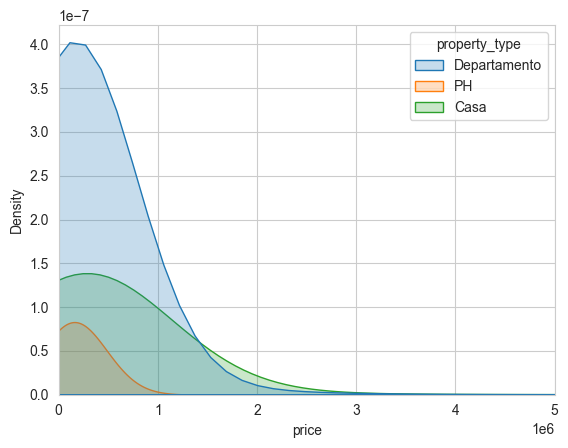

In [79]:
plt.figure()
sns.kdeplot(data=venta_usd, x='price', hue='property_type', fill=True, bw_adjust=20)
plt.xlim(0,5000000)
plt.show()


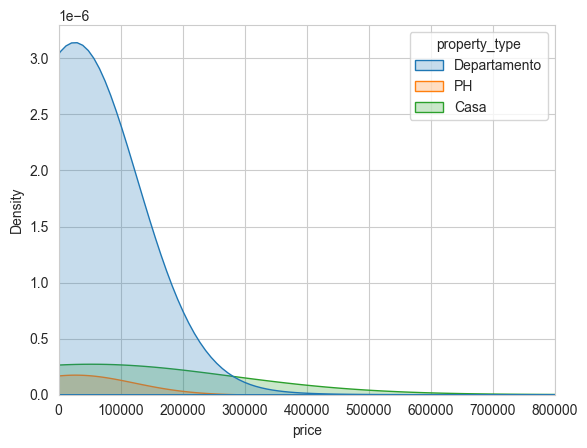

In [80]:
plt.figure()
sns.kdeplot(data=alquiler_ars, x='price', hue='property_type', fill=True, bw_adjust=20)
plt.xlim(0,800000)
plt.show()

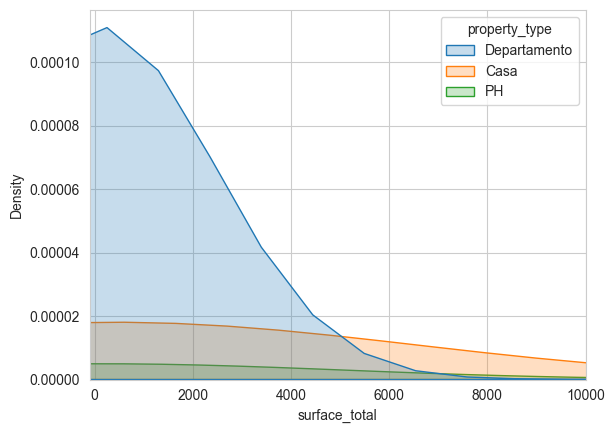

In [81]:
plt.figure()
sns.kdeplot(data=df, x='surface_total', hue='property_type', fill=True, bw_adjust=20)
plt.xlim(-100,10000)
plt.show()


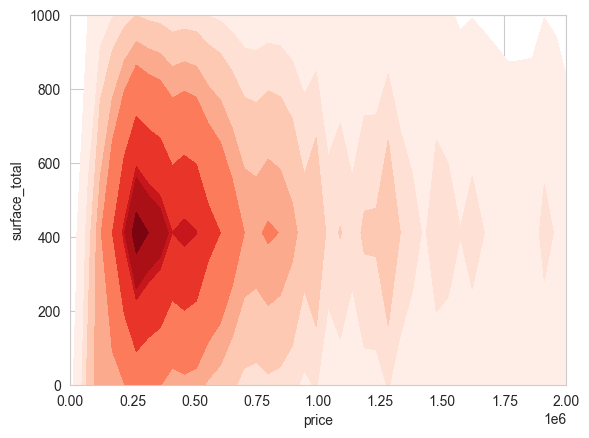

In [82]:
sns.kdeplot(data = venta_usd_caba, x='price', y='surface_total', cmap='Reds',fill=True,bw_adjust=0.5 )
plt.xlim(0,2000000)
plt.ylim(0,1000)
plt.show()

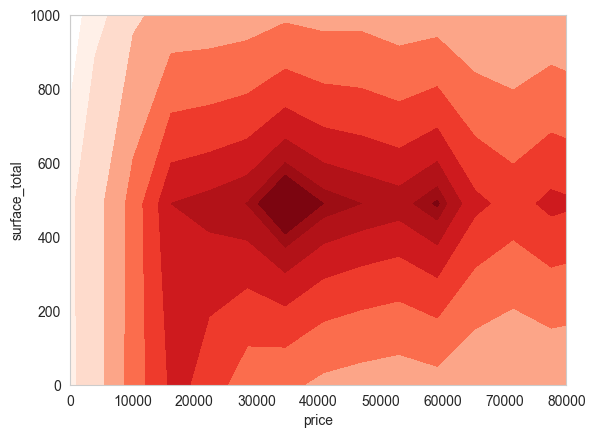

In [83]:
sns.kdeplot(data = alquiler_ars, x='price', y='surface_total', cmap='Reds',fill=True,bw_adjust=0.5 )
plt.xlim(0,80000)
plt.ylim(0,1000)
plt.show()

## Predicciones

In [84]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [85]:
df = df.drop(['start_date', 'end_date', 'l3'], axis=1, errors='ignore')

In [86]:
ohe = pd.get_dummies(df[['l2', 'currency',
                     'property_type', 'operation_type']]).astype(int)

In [87]:
df_nuevo = pd.concat([df.drop(['l2','currency','property_type','operation_type'], axis=1),ohe], axis=1)
df_nuevo

,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,l2_Bs.As. G.B.A. Zona Norte,l2_Bs.As. G.B.A. Zona Oeste,l2_Bs.As. G.B.A. Zona Sur,l2_Buenos Aires Costa Atlántica,...,l2_Santiago Del Estero,l2_Tierra Del Fuego,l2_Tucumán,currency_ARS,currency_USD,property_type_Casa,property_type_Departamento,property_type_PH,operation_type_Alquiler,operation_type_Venta
36,1.0,1.0,1.0,17.0,17.0,15000.0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
37,1.0,1.0,1.0,38.0,36.0,24000.0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
38,1.0,1.0,1.0,39.0,39.0,16500.0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
41,2.0,1.0,1.0,45.0,45.0,16000.0,0,0,1,0,...,0,0,0,1,0,0,1,0,1,0
45,2.0,1.0,1.0,39.0,38.0,21000.0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999967,6.0,5.0,5.0,580.0,580.0,1111111.0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1
999972,7.0,6.0,2.0,260.0,260.0,330000.0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1
999979,8.0,7.0,1.0,180.0,180.0,299001.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
999980,9.0,7.0,8.0,800.0,800.0,3800000.0,1,0,0,0,...,0,0,0,0,1,1,0,0,0,1


In [88]:
X = df_nuevo.drop(['price'], axis=1)
y = df_nuevo['price']

In [89]:
import sys
import joblib
sys.modules['sklearn.externals.joblib'] = joblib

#Librerias
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
# Sequential Forward Selection(sfs)
sfs = SFS(LinearRegression(),
          k_features=10,
          forward=True,
          floating=False,
          scoring = 'r2',
          cv = 0)

In [90]:
sfs.fit(X, y)
k_feat = list(sfs.k_feature_names_)

k_feat

['bedrooms',
 'bathrooms',
 'l2_Bs.As. G.B.A. Zona Norte',
 'l2_Capital Federal',
 'l2_Neuquén',
 'l2_Santa Fe',
 'currency_ARS',
 'property_type_Casa',
 'property_type_Departamento',
 'operation_type_Alquiler']

In [91]:
X = df_nuevo[k_feat]

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10)
lr = LinearRegression()

In [144]:
lr.fit(X_train, y_train)

LinearRegression()

In [145]:
y_pred_lr = lr.predict(X_test)

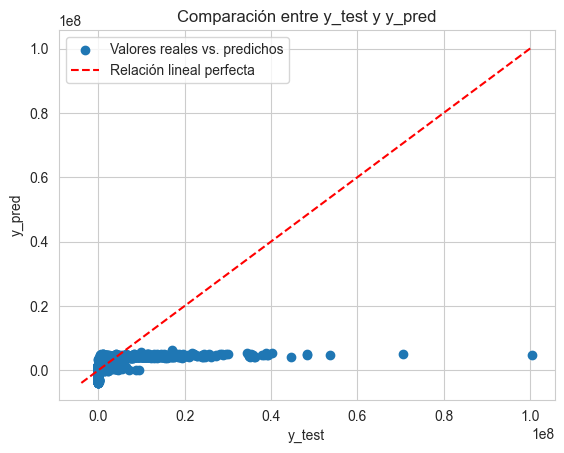

In [169]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la línea de referencia (relación lineal perfecta)
min_val = min(np.min(y_test), np.min(y_pred_lr))
max_val = max(np.max(y_test), np.max(y_pred_lr))
ref_line = np.linspace(min_val, max_val, 100)

# Graficar y_test vs y_pred con línea de referencia
plt.scatter(y_test, y_pred_lr, label='Valores reales vs. predichos')
plt.plot(ref_line, ref_line, color='red', linestyle='--', label='Relación lineal perfecta')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Comparación entre y_test y y_pred')
plt.legend()
plt.show()

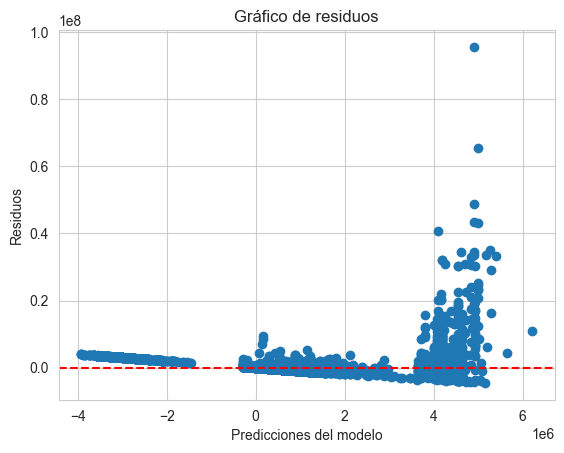

In [148]:
# Gráfico de residuos
residuals = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones del modelo')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.show()

In [149]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error

print("MAE", mean_absolute_error(y_test, y_pred_lr))
print("MSE", mean_squared_error(y_test, y_pred_lr))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("RMSE log", np.log(np.sqrt(mean_squared_error(y_test, y_pred_lr))))
r2 = r2_score(y_test, y_pred_lr)
print("r2 score: ", r2)

MAE 437126.5057416008
MSE 1885711446310.5767
RMSE 1373212.090796821
RMSE log 14.132663145360018
r2 score:  0.21099175491436017


In [150]:
from sklearn.tree import DecisionTreeRegressor

In [151]:
# Crear un modelo de árbol de decisión
dtr = DecisionTreeRegressor()

In [152]:
# Entrenar el modelo utilizando los datos de entrenamiento
dtr.fit(X_train, y_train)

DecisionTreeRegressor()

In [153]:
y_pred_dtr = dtr.predict(X_test)

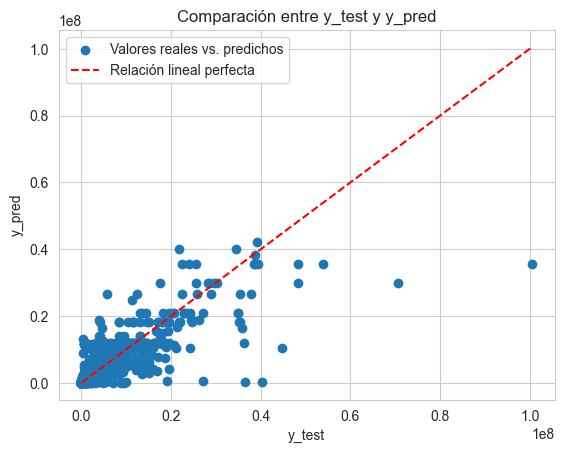

In [170]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la línea de referencia (relación lineal perfecta)
min_val = min(np.min(y_test), np.min(y_pred_dtr))
max_val = max(np.max(y_test), np.max(y_pred_dtr))
ref_line = np.linspace(min_val, max_val, 100)

# Graficar y_test vs y_pred con línea de referencia
plt.scatter(y_test, y_pred_dtr, label='Valores reales vs. predichos')
plt.plot(ref_line, ref_line, color='red', linestyle='--', label='Relación lineal perfecta')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Comparación entre y_test y y_pred')
plt.legend()
plt.show()

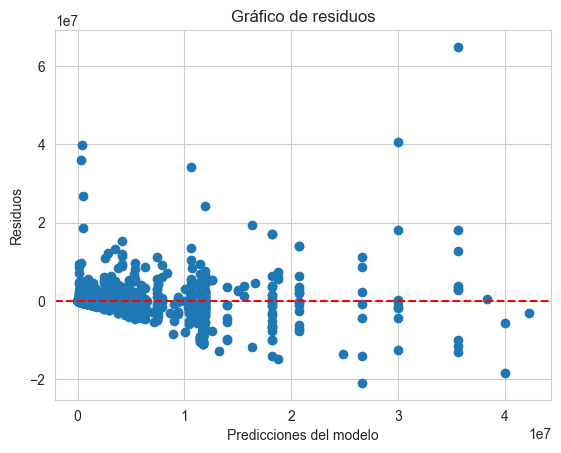

In [155]:
# Gráfico de residuos
residuals = y_test - y_pred_dtr
plt.scatter(y_pred_dtr, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones del modelo')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.show()

In [154]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error

print("MAE", mean_absolute_error(y_test, y_pred_dtr))
print("MSE", mean_squared_error(y_test, y_pred_dtr))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_dtr)))
print("RMSE log", np.log(np.sqrt(mean_squared_error(y_test, y_pred_dtr))))
r2 = r2_score(y_test, y_pred_dtr)
print("r2 score: ", r2)

MAE 140127.26675809873
MSE 675792326671.079
RMSE 822065.8894949231
RMSE log 13.619575828362276
r2 score:  0.7172389663581272


In [156]:
from sklearn.ensemble import RandomForestRegressor

In [158]:
rfr = RandomForestRegressor()

In [159]:
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [160]:
y_pred_rfr = rfr.predict(X_test)

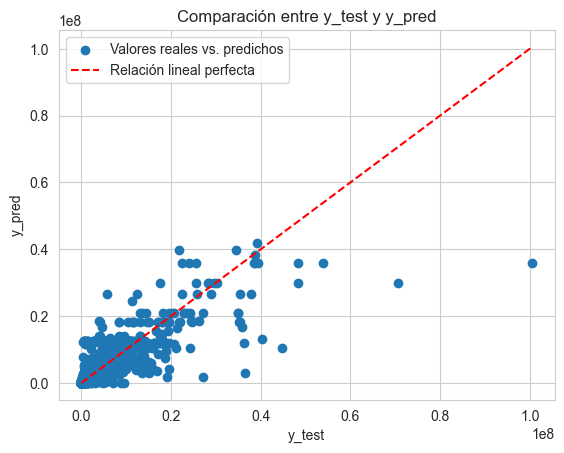

In [171]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la línea de referencia (relación lineal perfecta)
min_val = min(np.min(y_test), np.min(y_pred_rfr))
max_val = max(np.max(y_test), np.max(y_pred_rfr))
ref_line = np.linspace(min_val, max_val, 100)

# Graficar y_test vs y_pred con línea de referencia
plt.scatter(y_test, y_pred_rfr, label='Valores reales vs. predichos')
plt.plot(ref_line, ref_line, color='red', linestyle='--', label='Relación lineal perfecta')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Comparación entre y_test y y_pred')
plt.legend()
plt.show()

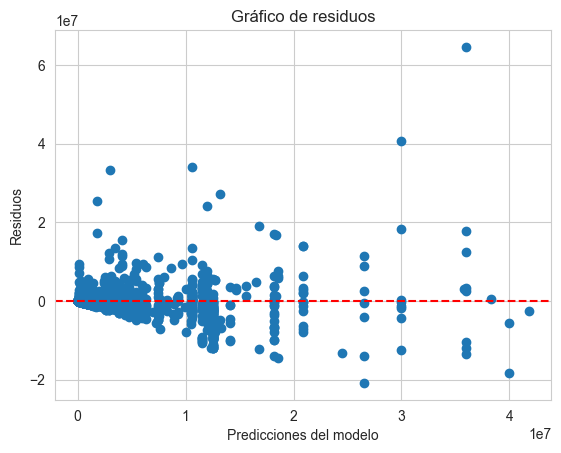

In [163]:
# Gráfico de residuos
residuals = y_test - y_pred_rfr
plt.scatter(y_pred_rfr, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones del modelo')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.show()

In [161]:
print("MAE", mean_absolute_error(y_test, y_pred_rfr))
print("MSE", mean_squared_error(y_test, y_pred_rfr))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_rfr)))
print("RMSE log", np.log(np.sqrt(mean_squared_error(y_test, y_pred_rfr))))
r2 = r2_score(y_test, y_pred_rfr)
print("r2 score: ", r2)

MAE 142204.11487596936
MSE 678284856140.074
RMSE 823580.509810713
RMSE log 13.621416589225737
r2 score:  0.7161960569002652


In [164]:
from sklearn.ensemble import GradientBoostingRegressor

In [165]:
gbr = GradientBoostingRegressor()

In [166]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor()

In [167]:
y_pred_gbr = gbr.predict(X_test)

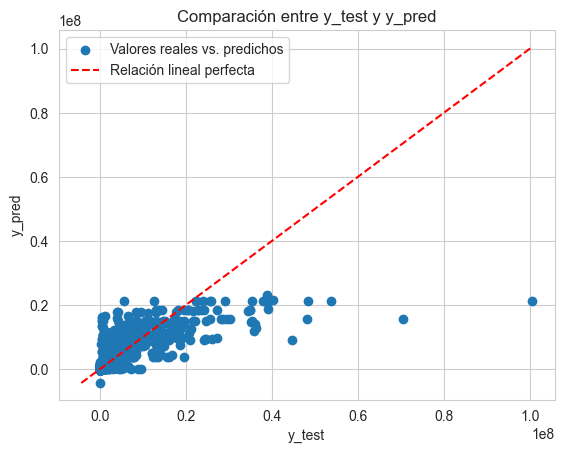

In [172]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la línea de referencia (relación lineal perfecta)
min_val = min(np.min(y_test), np.min(y_pred_gbr))
max_val = max(np.max(y_test), np.max(y_pred_gbr))
ref_line = np.linspace(min_val, max_val, 100)

# Graficar y_test vs y_pred con línea de referencia
plt.scatter(y_test, y_pred_gbr, label='Valores reales vs. predichos')
plt.plot(ref_line, ref_line, color='red', linestyle='--', label='Relación lineal perfecta')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Comparación entre y_test y y_pred')
plt.legend()
plt.show()

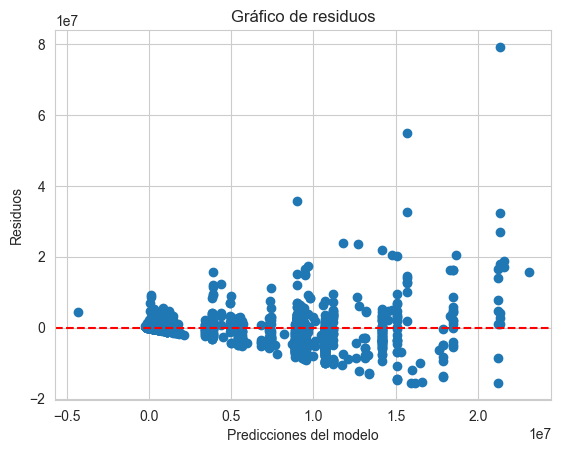

In [173]:
# Gráfico de residuos
residuals = y_test - y_pred_gbr
plt.scatter(y_pred_gbr, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones del modelo')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.show()

In [168]:
print("MAE", mean_absolute_error(y_test, y_pred_gbr))
print("MSE", mean_squared_error(y_test, y_pred_gbr))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("RMSE log", np.log(np.sqrt(mean_squared_error(y_test, y_pred_gbr))))
r2 = r2_score(y_test, y_pred_gbr)
print("r2 score: ", r2)

MAE 173115.48492455305
MSE 874880246328.9216
RMSE 935350.3334734647
RMSE log 13.74867642629964
r2 score:  0.6339377749619999


#### El modelo con los mejores resultados es el del arbol de decisiones con un r2 score de 0.71, eso quiere decir que este modelo explica un 71% de la variabilidad de la variable objetivo.
Debido a los resultados, podemos suponer un underfitting en el modelo de regresión lineal, mientras que los demás modelos podrían tener overfitting.


Para mejorar estos modelos se deberá realizar más ajustes al dataframe. Se pueden ajustar hiperparámetros y seguir evaluando continuamente el rendimiento